100%|██████████| 10/10 [00:00<00:00, 15.64it/s]


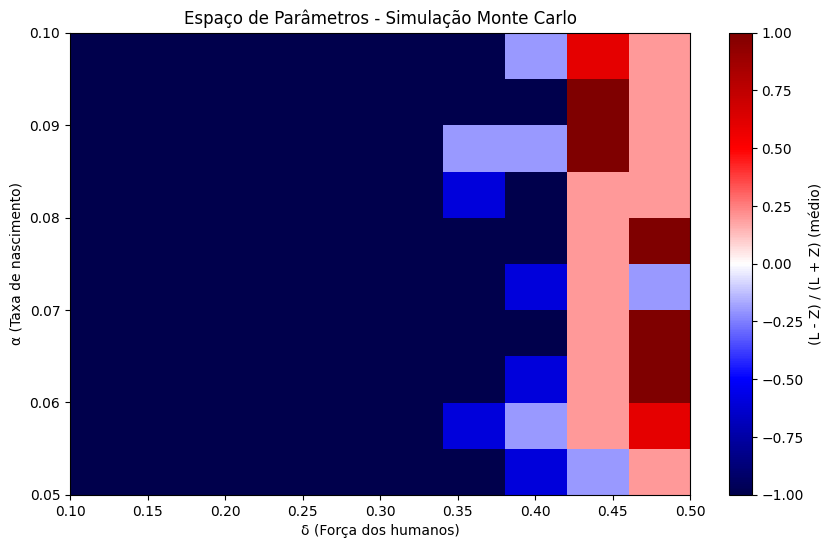

In [ ]:
from random import choices, randint, random
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

# Constantes fixas
beta = 0.2
gamma = 0.6
rho   = 0.1

# Malha de parâmetros
alphas = np.linspace(0.0, 1.0, 500)
deltas = np.linspace(0.0, 1.0, 500)

# Configurações da simulação
N0 = 150
p0 = 2/3
T = 20_000
n_sim = 5  # número de simulações por ponto

resultados = np.zeros((len(alphas), len(deltas)))

def simula(alpha, delta):
    pop = ['L'] * int(p0 * N0) + ['Z'] * int((1 - p0) * N0)
    for t in range(T):
        L = pop.count('L')
        Z = pop.count('Z')
        N = L + Z

        if L == 0 or Z == 0:
            break

        # Etapa 1: Confronto
        i1, i2 = randint(0, N - 1), randint(0, N - 1)
        if i1 != i2 and {'L', 'Z'} == {pop[i1], pop[i2]}:
            if pop[i1] == 'L':
                l_idx, z_idx = i1, i2
            else:
                l_idx, z_idx = i2, i1
            if random() < delta:
                pop.pop(z_idx)
            elif random() < gamma:
                pop[l_idx] = 'Z'

        # Etapa 2: Nascimento
        if pop.count('L') > 0 and random() < alpha:
            pop.append('L')

        # Etapa 3: Morte natural
        if pop.count('L') > 0 and random() < beta:
            idx = choices([i for i, v in enumerate(pop) if v == 'L'])[0]
            if random() < rho:
                pop[idx] = 'Z'
            else:
                pop.pop(idx)

    Lf = pop.count('L')
    Zf = pop.count('Z')
    if Lf + Zf > 0:
        return (Lf - Zf) / (Lf + Zf)
    else:
        return -1

# Loop principal
for i, alpha in tqdm(enumerate(alphas), total=len(alphas)):
    for j, delta in enumerate(deltas):
        media = np.mean([simula(alpha, delta) for _ in range(n_sim)])
        resultados[i, j] = media


plt.figure(figsize=(10, 6))
plt.imshow(resultados, origin='lower', aspect='auto',
           extent=[deltas[0], deltas[-1], alphas[0], alphas[-1]],
           cmap='seismic', vmin=-1, vmax=1)
plt.colorbar(label='(L - Z) / (L + Z) (médio)')
plt.xlabel('δ (Força dos humanos)')
plt.ylabel('α (Taxa de nascimento)')
plt.title('Espaço de Parâmetros - Simulação Monte Carlo')
plt.show()